In [1]:
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

/work/PENPAL/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
path = '/work/PENPAL/PENPAL_analysis/data/TEXT/processed/story_embeddings_interaction_level.parquet'

df_full = pd.read_parquet(path)
df = df_full[~df_full["respondent_id"].str.startswith("test-")]

In [8]:
df

,timestamp,user,ai,combined_prompt,client_id,workshop_id,language,conversation_id,respondent_id,user_embedding,ai_embedding
3,2025-11-13 12:34:34.539000+00:00,This is the story of\n\nThere once was a young...,"with her best friend, leaving her feeling shat...",NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[-0.009847976267337799, 0.0016179666854441166,...","[-0.006720611359924078, 0.006121717393398285, ..."
4,2025-11-13 12:36:05.046000+00:00,who claimed they loved her. This made her hard...,to take a chance and start attending social ev...,NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[-0.009516920894384384, 0.014092739671468735, ...","[-0.003943391144275665, -0.006826835218816996,..."
5,2025-11-13 12:37:38.170000+00:00,that she meet another young woman just like he...,"until one evening, when they both found themse...",NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[-0.012823346070945263, 0.001509161782450974, ...","[0.0023674711119383574, 0.0010259754490107298,..."
6,2025-11-13 12:39:04.145000+00:00,as if they where destined to meet. They starte...,"developed a deep and meaningful connection, on...",NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[0.004188875202089548, 0.00921684317290783, -0...","[0.0027713251765817404, -0.007644712459295988,..."
7,2025-11-13 12:40:11.365000+00:00,time whent on their connection became more tha...,had been afraid to acknowledge the true nature...,NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[-0.001402832567691803, 0.023314062505960464, ...","[-0.010389024391770363, -0.004656300414353609,..."
...,...,...,...,...,...,...,...,...,...,...,...
458,2025-11-06 12:28:08.840000+00:00,A house. It sits above the washbasin and is gr...,"more defined, but the scene in the clearing st...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.013003706932067871, 0.00976136326789856, 0...","[0.0035752165131270885, -0.005327609833329916,..."
459,2025-11-06 12:28:26.672000+00:00,The neighbors all say that the dust will pass....,"own. But as Ezra and I stood there, the dust s...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.0008603244205005467, -0.002290817676112055...","[0.0006013151723891497, 0.004016820341348648, ..."
460,2025-11-06 12:28:45.498000+00:00,Little Bessie and I go into town the next day ...,"cow, and she’s been a faithful companion throu...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.005458412226289511, 0.015171225182712078, ...","[-0.004755269270390272, 0.002042467473074794, ..."
461,2025-11-06 12:29:06.828000+00:00,"As we ride in, we see the new pop-up shop sell...","asks. But today, there's a different kind of e...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.007142434362322092, 0.0070573207922279835,...","[0.005576384719461203, -0.001296370755881071, ..."


### EngSent

In [9]:

MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
model.eval()

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [10]:
def get_sentiment_scores(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {
            "neg": np.nan, 
            "neu": np.nan, 
            "pos": np.nan, 
            "valence": np.nan,
            "label": None
        }

    # Tokenize
    inputs = tokenizer(text, return_tensors='pt', truncation=True)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).flatten().cpu().numpy()

    neg, neu, pos = probs

    # continuous valence score
    valence = float(pos - neg)

    # discrete label
    label_id = int(np.argmax(probs))
    label_map = {0: "negative", 1: "neutral", 2: "positive"}
    label = label_map[label_id]

    return {
        "neg": float(neg),
        "neu": float(neu),
        "pos": float(pos),
        "valence": valence,
        "label": label,
    }


In [11]:

# Expand dictionary into multiple columns
df_user_sent = df['user'].apply(get_sentiment_scores).apply(pd.Series)
df_ai_sent   = df['ai'].apply(get_sentiment_scores).apply(pd.Series)

# Add suffixes to columns so nothing clashes
df_user_sent = df_user_sent.add_prefix('user_')
df_ai_sent   = df_ai_sent.add_prefix('ai_')

# Merge into original df
df = pd.concat([df, df_user_sent, df_ai_sent], axis=1)


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [22]:
df.columns

Index(['timestamp', 'user', 'ai', 'combined_prompt', 'client_id',
       'workshop_id', 'language', 'conversation_id', 'respondent_id',
       'user_embedding', 'ai_embedding', 'user_neg', 'user_neu', 'user_pos',
       'user_valence', 'user_label', 'ai_neg', 'ai_neu', 'ai_pos',
       'ai_valence', 'ai_label', 'turn'],
      dtype='object')

In [12]:
df

,timestamp,user,ai,combined_prompt,client_id,workshop_id,language,conversation_id,respondent_id,user_embedding,...,user_neg,user_neu,user_pos,user_valence,user_label,ai_neg,ai_neu,ai_pos,ai_valence,ai_label
3,2025-11-13 12:34:34.539000+00:00,This is the story of\n\nThere once was a young...,"with her best friend, leaving her feeling shat...",NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[-0.009847976267337799, 0.0016179666854441166,...",...,0.760705,0.226074,0.013221,-0.747485,negative,0.803833,0.188335,0.007833,-0.796000,negative
4,2025-11-13 12:36:05.046000+00:00,who claimed they loved her. This made her hard...,to take a chance and start attending social ev...,NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[-0.009516920894384384, 0.014092739671468735, ...",...,0.703040,0.268145,0.028815,-0.674225,negative,0.013808,0.497737,0.488455,0.474647,neutral
5,2025-11-13 12:37:38.170000+00:00,that she meet another young woman just like he...,"until one evening, when they both found themse...",NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[-0.012823346070945263, 0.001509161782450974, ...",...,0.274835,0.681142,0.044023,-0.230811,neutral,0.043762,0.831424,0.124814,0.081052,neutral
6,2025-11-13 12:39:04.145000+00:00,as if they where destined to meet. They starte...,"developed a deep and meaningful connection, on...",NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[0.004188875202089548, 0.00921684317290783, -0...",...,0.004261,0.209786,0.785953,0.781692,positive,0.012665,0.344512,0.642823,0.630159,positive
7,2025-11-13 12:40:11.365000+00:00,time whent on their connection became more tha...,had been afraid to acknowledge the true nature...,NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[-0.001402832567691803, 0.023314062505960464, ...",...,0.007166,0.265896,0.726938,0.719771,positive,0.142382,0.719673,0.137945,-0.004437,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458,2025-11-06 12:28:08.840000+00:00,A house. It sits above the washbasin and is gr...,"more defined, but the scene in the clearing st...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.013003706932067871, 0.00976136326789856, 0...",...,0.655431,0.325442,0.019127,-0.636305,negative,0.027035,0.602675,0.370290,0.343254,neutral
459,2025-11-06 12:28:26.672000+00:00,The neighbors all say that the dust will pass....,"own. But as Ezra and I stood there, the dust s...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.0008603244205005467, -0.002290817676112055...",...,0.274867,0.623917,0.101216,-0.173651,neutral,0.056795,0.727458,0.215747,0.158953,neutral
460,2025-11-06 12:28:45.498000+00:00,Little Bessie and I go into town the next day ...,"cow, and she’s been a faithful companion throu...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.005458412226289511, 0.015171225182712078, ...",...,0.018699,0.316654,0.664647,0.645948,positive,0.005279,0.178763,0.815958,0.810678,positive
461,2025-11-06 12:29:06.828000+00:00,"As we ride in, we see the new pop-up shop sell...","asks. But today, there's a different kind of e...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.007142434362322092, 0.0070573207922279835,...",...,0.022350,0.496304,0.481346,0.458996,neutral,0.003330,0.143806,0.852865,0.849535,positive


In [19]:
df['turn'] = df.groupby('respondent_id').cumcount() + 1

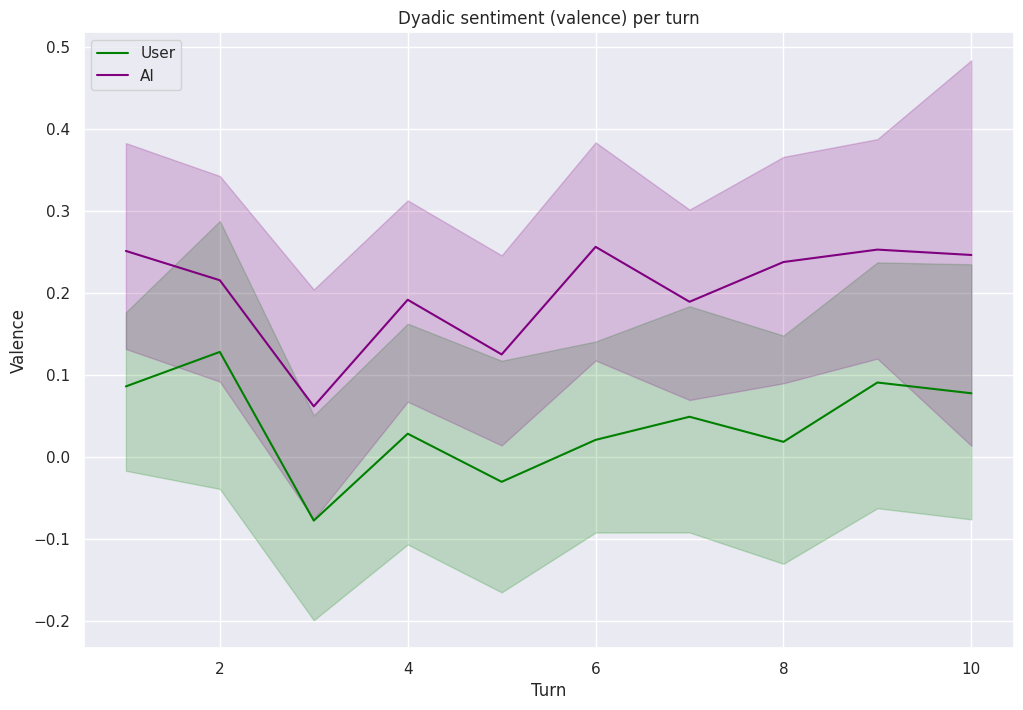

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.set_theme(style="darkgrid")

sns.lineplot(x="turn", y="user_valence", data=df, label="User", color="green")
sns.lineplot(x="turn", y="ai_valence", data=df, label="AI", color="purple")

plt.title("Dyadic sentiment (valence) per turn")
plt.xlabel("Turn")
plt.ylabel("Valence")
plt.legend()

plt.show()


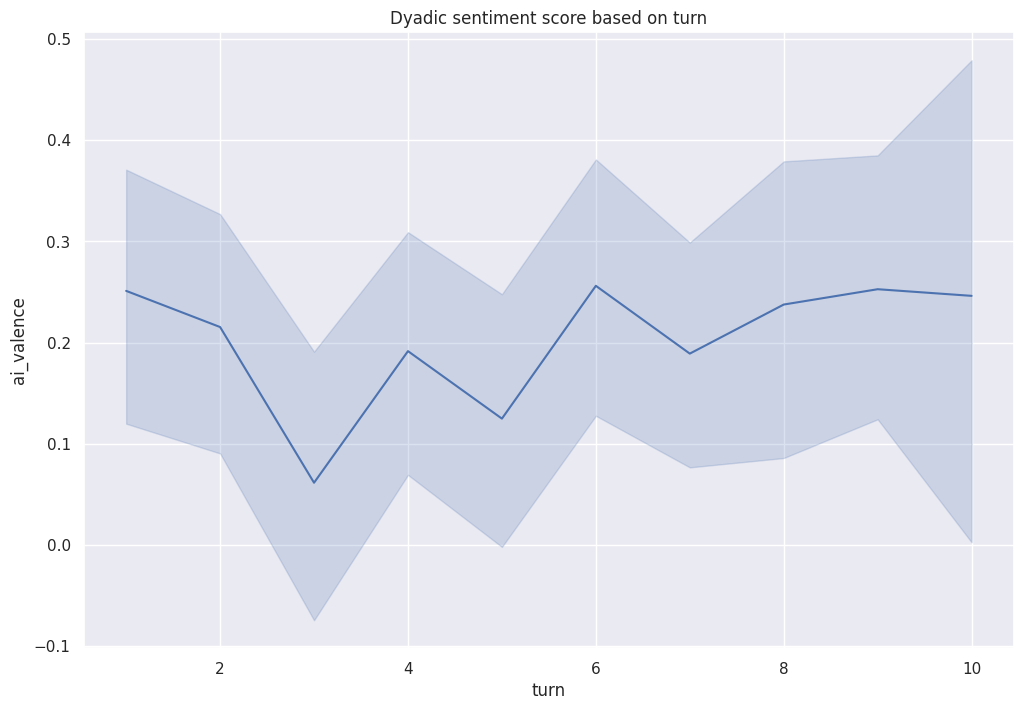

In [27]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.set_theme(style="darkgrid")
# Load an example dataset with long-form data

# Plot the responses for different events and regions
sns.lineplot(x="turn", y="ai_valence", data=df)
             
plt.title('Dyadic sentiment score based on turn')
plt.show()